# Optymalizacja Systemu Cyber-Fizycznego (CPS) w Inteligentnej Szklarni
Projekt analizuje dwa modele sterowania doświetlaniem roślin: **Reaktywny** oraz **Zaawansowany (Predykcyjny)**.
Celem jest osiągnięcie wymaganego wskaźnika **DLI (Daily Light Integral)** przy minimalizacji kosztów energii i śladu węglowego.

### Kluczowe parametry:
* **DLI**: Sumaryczna dawka światła [mol/m²/d].
* **PPFD**: Chwilowe natężenie światła [µmol/m²s].
* **CO2 Intensity**: Emisyjność sieci [g/kWh].

In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('plants_dataset.csv', parse_dates=['Timestamp'])

Wybieramy rośline: `pomidor(tomato)`

In [104]:
plant_type = 'Tomato'
df_filtered = df[df['Plant_Type'] == plant_type].sort_values('Timestamp')
wybrany_dzien = df_filtered['Timestamp'].dt.date.unique()[0]
test_day_raw = df_filtered[df_filtered['Timestamp'].dt.date == wybrany_dzien].copy()
full_day_range = pd.DataFrame({'Hour': range(24)})

test_day = pd.merge(full_day_range, test_day_raw, on='Hour', how='left')

test_day['Sunlight_Actual'] = test_day['Sunlight_Actual'].fillna(0)
test_day['Sunlight_Forecast'] = test_day['Sunlight_Forecast'].fillna(0)
mean_price = test_day['Price_PLN_kWh'].mean()
test_day['Price_PLN_kWh'] = test_day['Price_PLN_kWh'].fillna(mean_price)
test_day['Target_DLI'] = test_day['Target_DLI'].ffill().bfill()
test_day['Max_Threshold_Lux'] = test_day['Max_Threshold_Lux'].ffill().bfill()

print(f"Liczba punktów po uzupełnieniu: {len(test_day)}")

Liczba punktów po uzupełnieniu: 24


## Model Zaawansowany (Knowledge-Based)
Model ten wykorzystuje dane historyczne i prognozy, aby zaplanować doświetlanie w najtańszych i "najczystszych" (Low CO2) godzinach.

In [105]:
def smart_optimizer(row, dli_accumulated, hours_left):
    """
    Decyduje o mocy lamp na podstawie zapotrzebowania, prognozy i ceny.
    """
    # Cel do osiągnięcia
    target_remaining = max(0, row['Target_DLI'] - dli_accumulated)
    
    if target_remaining <= 0:
        return 0, 0  # Cel osiągnięty - wyłączamy lampy

    # Ile światła dostaniemy ze słońca teraz
    current_sun_dli = (row['Sunlight_Actual'] * 3600) / 1_000_000
    
    # Predykcja: ile słońca dostaniemy jeszcze dzisiaj
    expected_future_sun = (row['Sunlight_Forecast'] * min(hours_left, 5) * 3600) / 1_000_000
    
    led_power = 0
    # Decyzja CPS: Włączamy jeśli jest "tanio" lub jeśli to "ostatnia szansa" na cel
    is_cheap = row['Price_PLN_kWh'] < 0.65
    is_last_chance = hours_left < 6 and (target_remaining > expected_future_sun)

    if is_cheap or is_last_chance:
        # Obliczamy bezpieczną moc (fizyczna granica rośliny)
        max_safe_led = max(0, row['Max_Threshold_Lux'] - row['Sunlight_Actual'])
        
        # Obliczamy moc potrzebną, by nie świecić mocniej niż trzeba
        needed_now_ppfd = (target_remaining * 1_000_000) / 3600
        
        led_power = min(max_safe_led, needed_now_ppfd, 400) # 400 to max moc lampy

    led_dli = (led_power * 3600) / 1_000_000
    return round(led_power, 2), round(led_dli, 4)

### Symulacja doby

In [106]:
# Inicjalizacja wyników
dli_sum = 0
results = []

for i, row in test_day.iterrows():
    hours_left = 24 - row['Hour']
    led_p, l_dli = smart_optimizer(row, dli_sum, hours_left)
    sun_dli = (row['Sunlight_Actual'] * 3600) / 1_000_000
    dli_sum += (sun_dli + l_dli)
    
    results.append({
        'Hour': row['Hour'],
        'LED_Power': led_p,
        'Accumulated_DLI': dli_sum,
        'Price': row['Price_PLN_kWh']
    })

res_df = pd.DataFrame(results)

## Analiza Wyników i Test Odporności
Poniżej sprawdzamy, jak system poradził sobie z realizacją planu. 
W kolejnym kroku wprowadzimy **"zepsute dane"** (np. Sunlight_Actual = 0 w południe), aby zobaczyć reakcję mechanizmów weryfikacji (Kamera vs Czujnik).

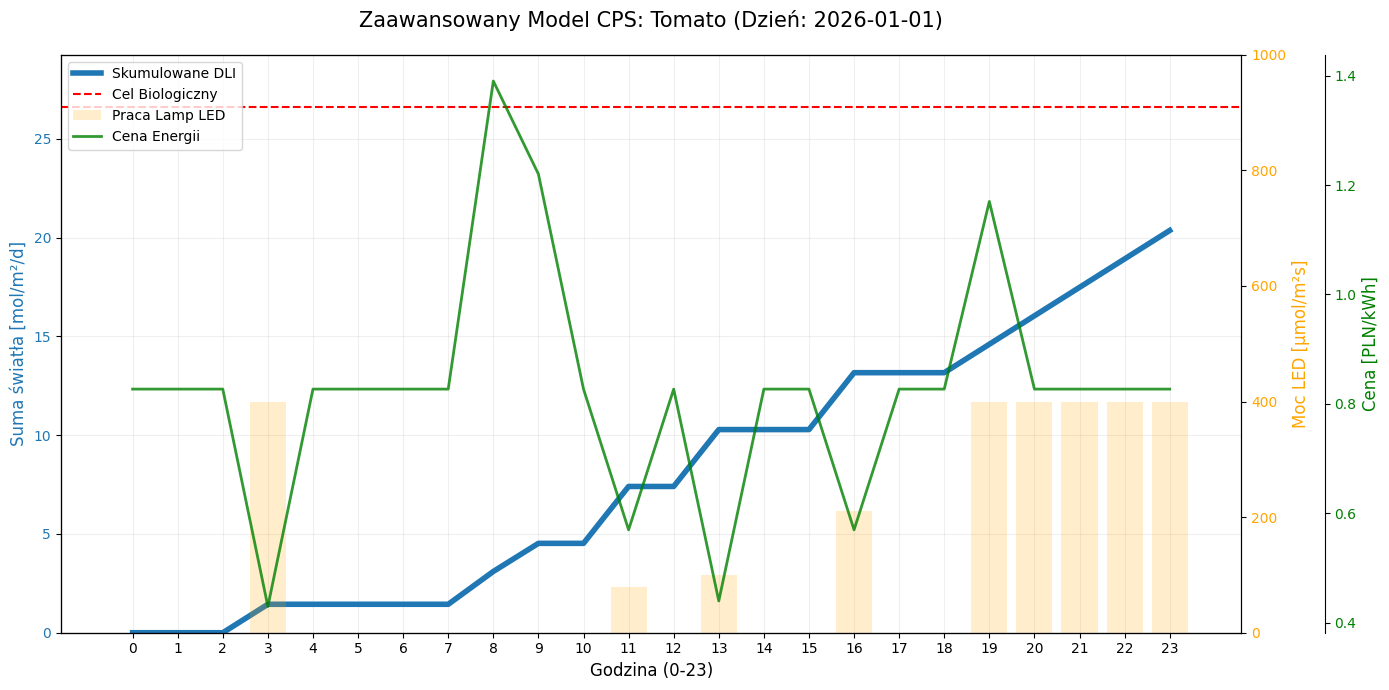

In [107]:
fig, ax1 = plt.subplots(figsize=(14, 7))

# DLI
ax1.plot(res_df['Hour'], res_df['Accumulated_DLI'], color='#1f77b4', linewidth=4, label='Skumulowane DLI')
ax1.axhline(y=test_day['Target_DLI'].iloc[0], color='red', linestyle='--', label='Cel Biologiczny')
ax1.set_ylabel('Suma światła [mol/m²/d]', color='#1f77b4', fontsize=12)
ax1.set_xlabel('Godzina (0-23)', fontsize=12)
ax1.set_xticks(range(0, 24))
ax1.set_ylim(0, max(res_df['Accumulated_DLI'].max(), test_day['Target_DLI'].iloc[0]) * 1.1)
ax1.tick_params(axis='y', labelcolor='#1f77b4')

# MOC LED 
ax2 = ax1.twinx()
ax2.bar(res_df['Hour'], res_df['LED_Power'], alpha=0.2, color='orange', label='Praca Lamp LED')
ax2.set_ylabel('Moc LED [µmol/m²s]', color='orange', fontsize=12)
ax2.tick_params(axis='y', labelcolor='orange')
ax2.set_ylim(0, 1000) 

#CENA
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(res_df['Hour'], res_df['Price'], color='green', alpha=0.8, linewidth=2, label='Cena Energii')
ax3.set_ylabel('Cena [PLN/kWh]', color='green', fontsize=12)
ax3.tick_params(axis='y', labelcolor='green')

plt.title(f'Zaawansowany Model CPS: {plant_type} (Dzień: {wybrany_dzien})', fontsize=15, pad=20)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left')

ax1.grid(alpha=0.2)
fig.tight_layout()
plt.show()

### Proste obliczenie kosztów

In [108]:
total_energy_kwh = res_df['LED_Power'].sum() * (1/1000) # uproszczone przeliczenie
total_cost = (res_df['LED_Power'] * res_df['Price']).sum() * (1/1000)

print(f"Całkowity koszt doświetlania tej doby: {total_cost:.2f} PLN")
print(f"Zużycie energii: {total_energy_kwh:.2f} kWh")
print(f"Uzyskane DLI: {res_df['Accumulated_DLI'].iloc[-1]:.2f} / {test_day['Target_DLI'].iloc[0]:.2f}")

Całkowity koszt doświetlania tej doby: 2.17 PLN
Zużycie energii: 2.79 kWh
Uzyskane DLI: 20.36 / 26.60


Stworzyc model "inteligenty" nie automatyczny, ktory dla daty i pomidora wyhdouje go. Model aktualizuje swoje dane plants_dataset_new_data.csv i moze przyjac z symulacji jakies zle dane

## Model inteligentny

Test na RandomForestRegressor

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestRegressor

class MLCultivationAgent:
    def __init__(self, database_path='plants_dataset.csv', output_path='plants_dataset_new_data.csv'):
        self.database_path = database_path
        self.output_path = output_path
        
        self.df = pd.read_csv(self.database_path)
        self.df['Timestamp'] = pd.to_datetime(self.df['Timestamp'])
        self.tomato_data = self.df[self.df['Plant_Type'] == 'Tomato'].sort_values('Timestamp')
        
        self.model = RandomForestRegressor(n_estimators=50, random_state=42)
        self.is_trained = False

    def train_on_history(self):
        """Trening modelu ML na obecnym stanie pamięci agenta"""
        X = []
        y = []
        
        unique_days = self.tomato_data['Timestamp'].dt.date.unique()
        full_day_range = pd.DataFrame({'Hour': range(24)})
        
        for day in unique_days:
            day_data_raw = self.tomato_data[self.tomato_data['Timestamp'].dt.date == day].sort_values('Hour')
            
            day_data = pd.merge(full_day_range, day_data_raw, on='Hour', how='left')
            day_data['Sunlight_Actual'] = day_data['Sunlight_Actual'].fillna(0)
            day_data['Price_PLN_kWh'] = day_data['Price_PLN_kWh'].fillna(day_data['Price_PLN_kWh'].mean()).fillna(0.60)
            day_data['Target_DLI'] = day_data['Target_DLI'].ffill().bfill()
            day_data['Max_Threshold_Lux'] = day_data['Max_Threshold_Lux'].ffill().bfill()
            
            dli_accumulated = 0
            target_dli = day_data['Target_DLI'].iloc[0]
            max_lux = day_data['Max_Threshold_Lux'].iloc[0]
            
            for _, row in day_data.iterrows():
                hour = int(row['Hour'])
                price = row['Price_PLN_kWh']
                sunlight = row['Sunlight_Actual']
                
                for action_power in [0, 150, 300]:
                    features = [hour, dli_accumulated, target_dli, price, sunlight, action_power]
                    
                    sun_dli_hour = (sunlight * 3600) / 1_000_000
                    led_dli_hour = (action_power * 3600) / 1_000_000
                    next_dli = dli_accumulated + sun_dli_hour + led_dli_hour
                    
                    cost = (action_power * price) / 1000
                    reward = -cost * 100
                    
                    if next_dli <= target_dli and action_power > 0:
                        reward += 15
                    if next_dli > target_dli and action_power > 0:
                        reward -= 50
                    if sunlight + action_power > max_lux:
                        reward -= 300
                        
                    X.append(features)
                    y.append(reward)
                    
                dli_accumulated += (sun_dli_hour + (150 * 3600) / 1_000_000)

        X = np.array(X)
        y = np.array(y)
        
        if len(X) == 0:
            raise ValueError("Błąd: Zbiór treningowy jest pusty.")
            
        self.model.fit(X, y)
        self.is_trained = True

    def grow_tomato(self, target_date):
        """Generowanie predykcji, zapis do pliku oraz adaptacja modelu o nowy rekord"""
        if not self.is_trained:
            raise ValueError("Model musi zostać najpierw wytrenowany.")
            
        target_date = pd.to_datetime(target_date).date()
        day_data_raw = self.tomato_data[self.tomato_data['Timestamp'].dt.date == target_date].sort_values('Hour')
        
        full_day_range = pd.DataFrame({'Hour': range(24)})
        day_data = pd.merge(full_day_range, day_data_raw, on='Hour', how='left')
        
        day_data['Sunlight_Actual'] = day_data['Sunlight_Actual'].fillna(0)
        day_data['Price_PLN_kWh'] = day_data['Price_PLN_kWh'].fillna(day_data['Price_PLN_kWh'].mean()).fillna(0.60)
        day_data['Target_DLI'] = day_data['Target_DLI'].ffill().bfill()
        day_data['Max_Threshold_Lux'] = day_data['Max_Threshold_Lux'].ffill().bfill()
        day_data['Growth_Stage'] = day_data['Growth_Stage'].ffill().bfill()
        day_data['NDVI_Camera_Index'] = day_data['NDVI_Camera_Index'].ffill().bfill()
        day_data['Plant_Type'] = day_data['Plant_Type'].fillna('Tomato')

        dli_accumulated = 0
        executed_logs = []
        target_dli = day_data['Target_DLI'].iloc[0]

        for i, row in day_data.iterrows():
            hour = int(row['Hour'])
            price = row['Price_PLN_kWh']
            sunlight = row['Sunlight_Actual']
            
            best_action = 0
            best_predicted_reward = -float('inf')
            
            for action_power in [0, 150, 300]:
                input_features = np.array([[hour, dli_accumulated, target_dli, price, sunlight, action_power]])
                predicted_reward = self.model.predict(input_features)[0]
                
                if predicted_reward > best_predicted_reward:
                    best_predicted_reward = predicted_reward
                    best_action = action_power
            
            led_power = best_action
            if sunlight + led_power > row['Max_Threshold_Lux']:
                led_power = 0

            sun_dli_hour = (sunlight * 3600) / 1_000_000
            led_dli_hour = (led_power * 3600) / 1_000_000
            dli_accumulated += (sun_dli_hour + led_dli_hour)

            current_ts = row['Timestamp'] if not pd.isna(row['Timestamp']) else pd.Timestamp(f"{target_date} {hour:02d}:00:00")

            executed_logs.append({
                'Timestamp': current_ts, 'Hour': hour, 'Plant_Type': 'Tomato',
                'Growth_Stage': row['Growth_Stage'], 'NDVI_Camera_Index': row['NDVI_Camera_Index'],
                'Sunlight_Actual': sunlight, 'Price_PLN_kWh': price,
                'Target_DLI': target_dli, 'LED_Power_Executed': led_power, 'Accumulated_DLI': dli_accumulated
            })

        new_day_df = pd.DataFrame(executed_logs)
        header_needed = not os.path.exists(self.output_path)
        new_day_df.to_csv(self.output_path, mode='a', header=header_needed, index=False)
        
        self.tomato_data = pd.concat([self.tomato_data, new_day_df], ignore_index=True)
        self.train_on_history()
        
        return new_day_df

In [110]:
import matplotlib.pyplot as plt

def plot_results(results_df, plant_type, date_str):
    """
    Generuje trójosiowy wykres prezentujący wyniki symulacji CPS z użyciem modelu ML.
    """
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # OŚ 1: DLI
    ax1.plot(results_df['Hour'], results_df['Accumulated_DLI'], color='#1f77b4', linewidth=4, label='Skumulowane DLI')
    ax1.axhline(y=results_df['Target_DLI'].iloc[0], color='red', linestyle='--', label='Cel Biologiczny (Target)')
    ax1.set_ylabel('Suma światła [mol/m²/d]', color='#1f77b4', fontsize=12)
    ax1.set_xlabel('Godzina (0-23)', fontsize=12)
    ax1.set_xticks(range(0, 24))
    ax1.tick_params(axis='y', labelcolor='#1f77b4')
    
    max_dli_val = max(results_df['Accumulated_DLI'].dropna().max(), results_df['Target_DLI'].iloc[0])
    ax1.set_ylim(0, max_dli_val * 1.1)

    # OŚ 2: MOC LED
    ax2 = ax1.twinx()
    ax2.bar(results_df['Hour'], results_df['LED_Power_Executed'], alpha=0.2, color='orange', label='Praca Lamp LED')
    ax2.set_ylabel('Moc LED [µmol/m²s]', color='orange', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='orange')
    ax2.set_ylim(0, 500) 

    # OŚ 3: CENA
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.plot(results_df['Hour'], results_df['Price_PLN_kWh'], color='green', alpha=0.8, linewidth=2, label='Cena Energii')
    ax3.set_ylabel('Cena [PLN/kWh]', color='green', fontsize=12)
    ax3.tick_params(axis='y', labelcolor='green')

    # Tytuł dostosowany do klasycznego modelu Machine Learning
    plt.title(f'Model CPS (ML Random Forest): {plant_type} (Dzień: {date_str})', fontsize=15, pad=20)
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left')

    ax1.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()

In [111]:
ml_agent = MLCultivationAgent()
ml_agent.train_on_history()

In [112]:
wybrana_data = '2027-01-02'
results = ml_agent.grow_tomato(target_date=wybrana_data)

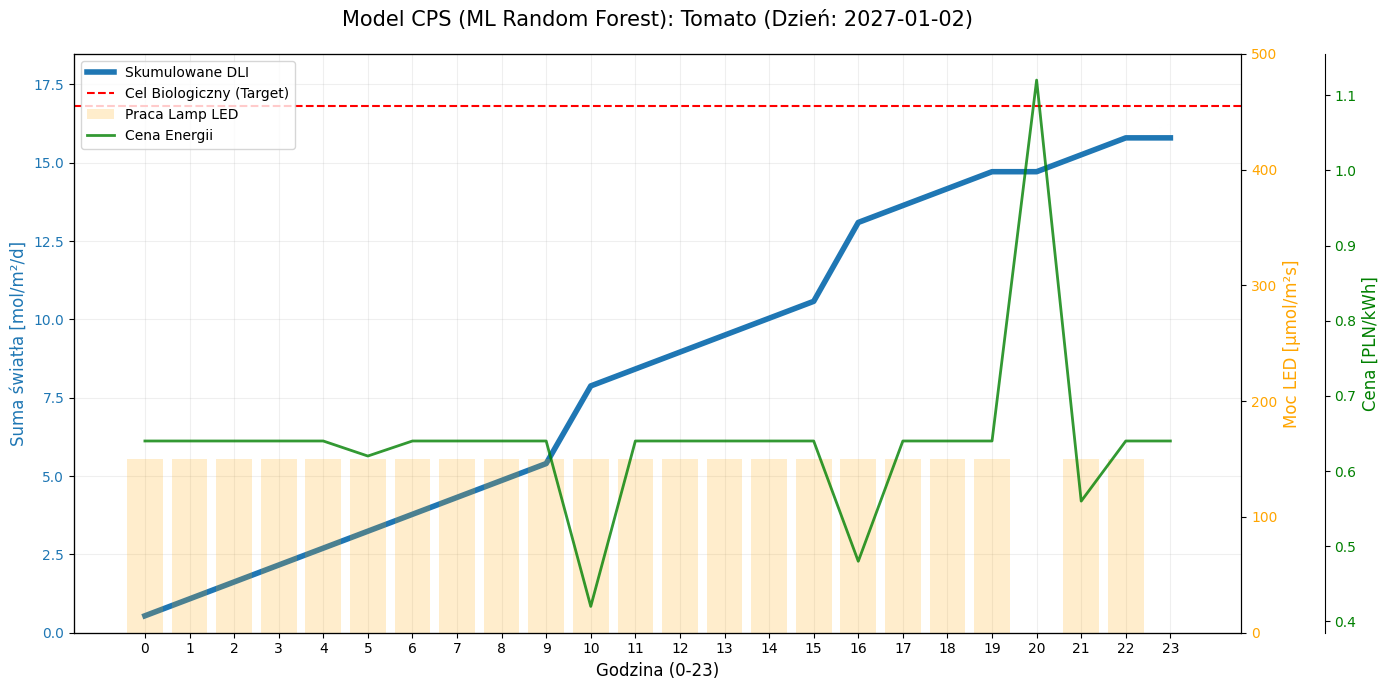

In [113]:
plot_results(results, plant_type='Tomato', date_str=wybrana_data)

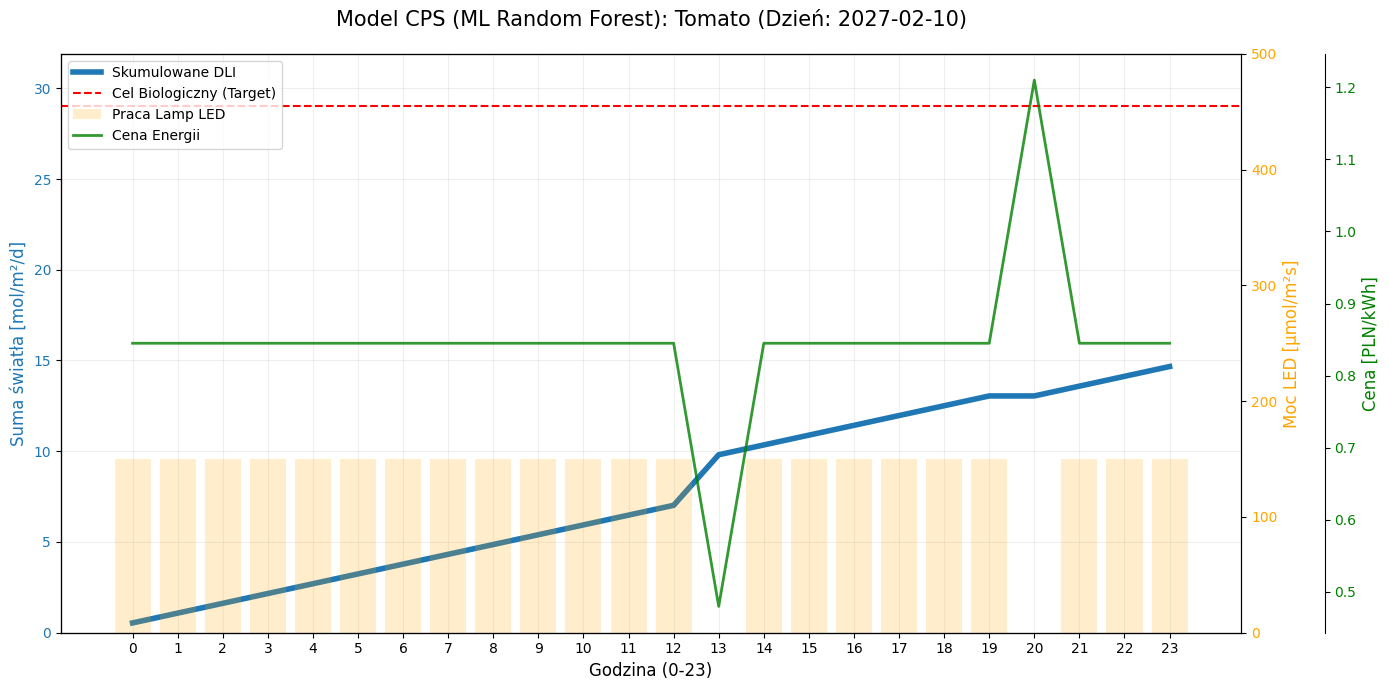

In [114]:
wybrana_data = '2027-02-10'
results2 = ml_agent.grow_tomato(target_date=wybrana_data)
plot_results(results2, 'Tomato', wybrana_data)